In [ ]:
# Install fiftyone for dataset management
!pip install fiftyone #library for working with cv

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import fiftyone as fo
import fiftyone.zoo as foz
import os
import cv2
import numpy as np
from PIL import Image

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 118.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.5/934.5 kB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 19.0 MB/s eta

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


In [ ]:
#Download and format datasets
# Define your major project classes
classes = ["person", "cell phone", "book", "laptop"]

print("Downloading dataset...")
dataset = foz.load_zoo_dataset(
    "coco-2017",
    split="validation", # Using validation split as it's smaller and faster to download
    label_types=["detections"],
    classes=classes,
    max_samples=5000,
    only_matching=True,
)

# Export to standard YOLO format
export_dir = "/content/custom_yolo_data"
dataset.export(
    export_dir=export_dir,
    dataset_type=fo.types.YOLOv5Dataset,
    label_field="ground_truth",
    classes=classes,
)
print(f"Dataset ready at {export_dir}")

INFO:fiftyone.zoo.datasets:Downloading split 'validation' to '/root/fiftyone/coco-2017/validation' if necessary


Found annotations at '/root/fiftyone/coco-2017/raw/instances_val2017.json'


INFO:fiftyone.utils.coco:Found annotations at '/root/fiftyone/coco-2017/raw/instances_val2017.json'


Only found 2911 (<5000) samples matching your requirements


100 images found; downloading the remaining 2811


...

INFO:fiftyone.zoo.datasets:Dataset 'coco-2017-validation-5000' created


Directory '/content/custom_yolo_data' already exists; export will be merged with existing files


 100% |███████████████| 2911/2911 [8.3s elapsed, 0s remaining, 514.0 samples/s]       


INFO:eta.core.utils: 100% |███████████████| 2911/2911 [8.3s elapsed, 0s remaining, 514.0 samples/s]       


Dataset ready at /content/custom_yolo_data


In [ ]:
#Custom Pytorch Dataset
class CustomYoloDataset(Dataset):
    def __init__(self, img_dir, label_dir, S=7, B=2, C=4, transform=None): #s=7*7 grid,b=bounding box, c=classes
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.S = S
        self.B = B
        self.C = C
        self.image_files = sorted([f for f in os.listdir(img_dir) if f.endswith('.jpg')]) #sort alphabetically img

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):   #runs every time a sample is requested.
        img_name = self.image_files[index]
        img_path = os.path.join(self.img_dir, img_name) #the data set does not store label filename explicitly
        label_path = os.path.join(self.label_dir, img_name.replace('.jpg', '.txt')) #derive the label filename from the image filename

        # load image and converts to RGB
        image = Image.open(img_path).convert("RGB")

        # Load labels (class, x_center, y_center, width, height)
        boxes = [] #Stores all objects in that image
        if os.path.exists(label_path):
            with open(label_path, 'r') as f: #open label files
                for line in f.readlines(): #read each object
                    class_label, x, y, w, h = map(float, line.split()) #converts values to numbers
                    boxes.append([int(class_label), x, y, w, h]) #store them in a list

        if self.transform: #apply transformation(userdefined)
            image = self.transform(image)

        # Convert bounding boxes to our S x S grid matrix
        # Matrix shape: (7, 7, 14)
        label_matrix = torch.zeros((self.S, self.S, self.C + 5 * self.B)) #5=1confidence and x,y,w,h

        for box in boxes: #loop through all the objects in the images
            class_label, x, y, w, h = box #each box looks like
            class_label = int(class_label) #ensure class index is an integer

            # Determine which grid cell (i, j) the center of the box falls into
            i, j = int(self.S * y), int(self.S * x)

            # Calculate coordinates relative to the specific grid cell [0 to 1]
            x_cell, y_cell = self.S * x - j, self.S * y - i

            # Width and height relative to the whole image
            width_cell, height_cell = w, h

            # If no object already exists in this grid cell
            if label_matrix[i, j, self.C] == 0:
                # Set that an object exists (confidence = 1)
                label_matrix[i, j, self.C] = 1

                # Set box coordinates
                box_coordinates = torch.tensor([x_cell, y_cell, width_cell, height_cell]) #store bounding box
                label_matrix[i, j, self.C+1:self.C+5] = box_coordinates #put in label matrix

                # Set one-hot encoding for the class: It converts a class label (number) into a format the neural network can understand and learn from.
                label_matrix[i, j, class_label] = 1

        return image, label_matrix

In [ ]:
import torch
import torch.nn as nn

class DeeperObjectDetector(nn.Module):
    def __init__(self, split_size=7, num_boxes=2, num_classes=4):
        super(DeeperObjectDetector, self).__init__()
        self.S, self.B, self.C = split_size, num_boxes, num_classes

        # --- EXPANDED CNN BACKBONE (6 Layers) ---
        self.backbone = nn.Sequential(
            # Block 1 (Input: 448x448 -> Output: 112x112)
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2 (Output: 56x56)
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192), nn.LeakyReLU(0.1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3 (Output: 28x28)
            nn.Conv2d(192, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4 (Output: 14x14)
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.LeakyReLU(0.1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 5 - NEW (Output: 7x7)
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024), nn.LeakyReLU(0.1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 6 - NEW (Output: 7x7)
            # Adds more non-linearity and feature combinations without shrinking the grid
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024), nn.LeakyReLU(0.1),
        )

        # --- UPDATED DECISION HEAD ---
        self.head = nn.Sequential(
            nn.Flatten(),
            # Input size is now 1024 channels * 7 height * 7 width
            nn.Linear(1024 * 7 * 7, 2048), #Channels are the number of feature maps(defined in the convolutional layer)
            nn.Dropout(0.5), nn.LeakyReLU(0.1),
            # Final output must match our grid tensor requirements
            nn.Linear(2048, self.S * self.S * (self.C + self.B * 5))
        )

    def forward(self, x): #workflow
        x = self.backbone(x) #Backbone = the feature extractor part of the model
        x = self.head(x)
        return x.view(-1, self.S, self.S, self.C + self.B * 5) #image goes through backbone → head → reshaped into YOLO grid predictions,

# Initialize the new, deeper model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeeperObjectDetector(split_size=7, num_boxes=2, num_classes=4).to(device)

print("Deeper architecture initialized and moved to GPU!")

Deeper architecture initialized and moved to GPU!


In [ ]:
#Loss Function - Intersection over Union
def intersection_over_union(boxes_preds, boxes_labels):
    # Convert midpoint format (x,y,w,h) to corner format (x1,y1,x2,y2)
    box1_x1 = boxes_preds[..., 0:1] - boxes_preds[..., 2:3] / 2
    box1_y1 = boxes_preds[..., 1:2] - boxes_preds[..., 3:4] / 2
    box1_x2 = boxes_preds[..., 0:1] + boxes_preds[..., 2:3] / 2
    box1_y2 = boxes_preds[..., 1:2] + boxes_preds[..., 3:4] / 2

    box2_x1 = boxes_labels[..., 0:1] - boxes_labels[..., 2:3] / 2
    box2_y1 = boxes_labels[..., 1:2] - boxes_labels[..., 3:4] / 2
    box2_x2 = boxes_labels[..., 0:1] + boxes_labels[..., 2:3] / 2
    box2_y2 = boxes_labels[..., 1:2] + boxes_labels[..., 3:4] / 2

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
    box1_area = abs((box1_x2 - box1_x1) * (box1_y2 - box1_y1))
    box2_area = abs((box2_x2 - box2_x1) * (box2_y2 - box2_y1))
    union = box1_area + box2_area - intersection + 1e-6

    return intersection / union

class YoloLoss(nn.Module):
    def __init__(self, S=7, B=2, C=4):
        super(YoloLoss, self).__init__()
        self.mse = nn.MSELoss(reduction="sum")
        self.S, self.B, self.C = S, B, C
        self.lambda_coord = 5
        self.lambda_noobj = 0.5

    def forward(self, predictions, target):
        # target shape: (batch, 7, 7, 14)

        # Determine if an object exists in the cell (Confidence > 0)
        exists_box = target[..., self.C].unsqueeze(3) # Shape: (batch, 7, 7, 1)

        # ======================== #
        #   FOR OBJECT BOXES       #
        # ======================== #
        # If box exists, calculate localization loss (coordinates)
        box_predictions = exists_box * predictions[..., self.C+1:self.C+5]
        box_targets = exists_box * target[..., self.C+1:self.C+5]

        # Penalize width and height less for large boxes than small boxes using square root
        box_predictions[..., 2:4] = torch.sign(box_predictions[..., 2:4]) * torch.sqrt(torch.abs(box_predictions[..., 2:4] + 1e-6))
        box_targets[..., 2:4] = torch.sqrt(box_targets[..., 2:4])

        loss_coord = self.mse(torch.flatten(box_predictions, end_dim=-2), torch.flatten(box_targets, end_dim=-2))

        # Calculate objectness loss (confidence)
        pred_box_conf = exists_box * predictions[..., self.C:self.C+1]
        loss_obj = self.mse(torch.flatten(pred_box_conf), torch.flatten(exists_box))

        # Calculate classification loss
        pred_class = exists_box * predictions[..., :self.C]
        target_class = exists_box * target[..., :self.C]
        loss_class = self.mse(torch.flatten(pred_class, end_dim=-2), torch.flatten(target_class, end_dim=-2))

        # ======================== #
        #   FOR NO OBJECT BOXES    #
        # ======================== #
        no_exists_box = 1 - exists_box
        no_obj_conf = no_exists_box * predictions[..., self.C:self.C+1]
        loss_noobj = self.mse(torch.flatten(no_obj_conf), torch.flatten(no_exists_box * target[..., self.C:self.C+1]))

        # Final Composite Loss
        loss = (self.lambda_coord * loss_coord + loss_obj + self.lambda_noobj * loss_noobj + loss_class)
        return loss

        #This loss function teaches YOLO to: find objects, place boxes correctly, classify them, and avoid false detections.

In [ ]:
#training Loop
# Hyperparameters
LEARNING_RATE = 2e-5 #e=10^ ,#learing rate that controls how quickly the model learns during training.
BATCH_SIZE = 8 #8 images at once
EPOCHS = 50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# Transformations (Resize to 448x448 and convert to PyTorch Tensor)
transform = transforms.Compose([
    transforms.Resize((448, 448)), #Resized to 448×448 (YOLO standard)
    transforms.ToTensor(),
])

# Load Dataset
img_dir = "/content/custom_yolo_data/images/val"
label_dir = "/content/custom_yolo_data/labels/val"

dataset = CustomYoloDataset(img_dir, label_dir, transform=transform) #Loads images + labels
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True) #Groups them into batches and shufle the data

# Initialize Model, Loss, and Optimizer
model = CustomObjectDetector().to(device)
criterion = YoloLoss() #criterion loss function used here(Measures how wrong predictions are)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE) #lr=how well model learduring training it determine the size of step to be taken

# Training Loop
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch_idx, (images, targets) in enumerate(train_loader): #Loop over batches
        images, targets = images.to(device), targets.to(device) #Send data to GPU/CPU

        optimizer.zero_grad() #Clear old gradients
        predictions = model(images)
        loss = criterion(predictions, targets) #Compute loss
        loss.backward()
        optimizer.step() #updating the model parameters

        total_loss += loss.item() #keep track of error (Error = how different your prediction is from the actual answer)

    print(f"Epoch [{epoch+1}/{EPOCHS}] Average Loss: {total_loss/len(train_loader):.4f}")

print("Training cycle completed!")

Training on: cuda
Epoch [1/50] Average Loss: 181.7490
Epoch [2/50] Average Loss: 125.5415
Epoch [3/50] Average Loss: 108.4177
Epoch [4/50] Average Loss: 102.7196
Epoch [5/50] Average Loss: 103.4506
Epoch [6/50] Average Loss: 94.4865
Epoch [7/50] Average Loss: 101.0181
Epoch [8/50] Average Loss: 89.5503
Epoch [9/50] Average Loss: 92.5207
Epoch [10/50] Average Loss: 86.8677
Epoch [11/50] Average Loss: 80.7483
Epoch [12/50] Average Loss: 92.5160
Epoch [13/50] Average Loss: 75.9772
Epoch [14/50] Average Loss: 75.4952
Epoch [15/50] Average Loss: 70.8546
Epoch [16/50] Average Loss: 70.9663
Epoch [17/50] Average Loss: 73.8943
Epoch [18/50] Average Loss: 70.6312
Epoch [19/50] Average Loss: 81.7266
Epoch [20/50] Average Loss: 77.8715
Epoch [21/50] Average Loss: 75.8892
Epoch [22/50] Average Loss: 68.2703
Epoch [23/50] Average Loss: 68.1190
Epoch [24/50] Average Loss: 65.3318
Epoch [25/50] Average Loss: 69.3807
Epoch [26/50] Average Loss: 69.9326
Epoch [27/50] Average Loss: 68.1061
Epoch [28/50]

1. Upload image
2. Model predicts MANY boxes
3. Filter weak predictions
4. Remove duplicates (NMS:Non-Maximum Suppression)(overlapping boxes)
5. Draw final boxes

Please upload an image to test (JPG or PNG):


Saving multipleperson.jpeg to multipleperson (3).jpeg


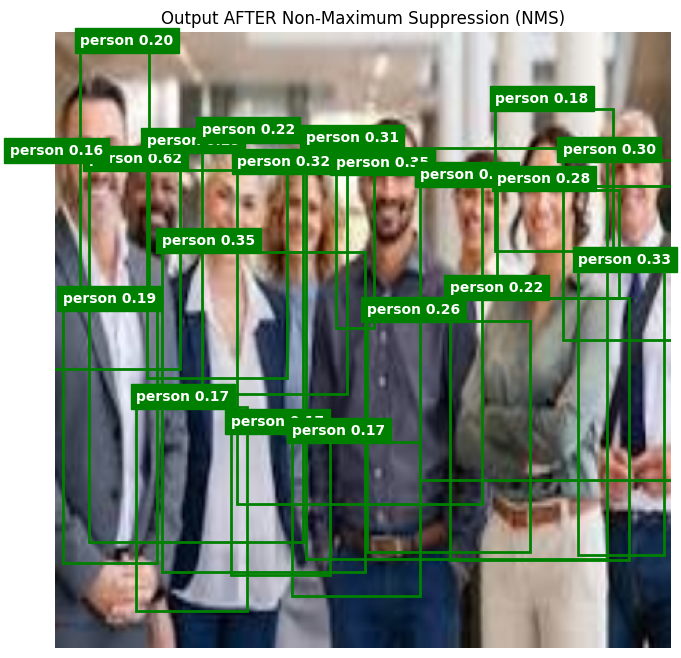

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from google.colab import files
import io

def test_custom_image_with_nms(model, conf_threshold=0.2, nms_threshold=0.4):
    print("Please upload an image to test (JPG or PNG):")
    uploaded = files.upload()
    if not uploaded: return
    filename = next(iter(uploaded))

    image = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")
    transform = transforms.Compose([transforms.Resize((448, 448)), transforms.ToTensor()])
    image_tensor = transform(image)
    image_batch = image_tensor.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        predictions = model(image_batch) #Model prediction

    pred_grid = predictions.squeeze(0).cpu()
    image_np = image_tensor.permute(1, 2, 0).numpy()
    classes = ["person", "cell phone", "book", "laptop"]

    # --- 1. COLLECT ALL VALID PREDICTIONS ---
    boxes_list = []
    scores_list = []
    labels_list = []

    for i in range(7):
        for j in range(7):
            confidence = pred_grid[i, j, 4].item()

            # Filter by confidence threshold first
            if confidence > conf_threshold:
                class_probs = pred_grid[i, j, 0:4]
                class_idx = torch.argmax(class_probs).item()

                # Decode relative grid coordinates to absolute pixel coordinates
                x_cell, y_cell = pred_grid[i, j, 5], pred_grid[i, j, 6]
                w_img, h_img = pred_grid[i, j, 7], pred_grid[i, j, 8]

                x_abs = (j + x_cell) / 7.0
                y_abs = (i + y_cell) / 7.0

                x_pixel = x_abs * 448
                y_pixel = y_abs * 448
                w_pixel = w_img * 448
                h_pixel = h_img * 448

                # NMS requires boxes in [x1, y1, x2, y2] format
                x1 = x_pixel - (w_pixel / 2)
                y1 = y_pixel - (h_pixel / 2)
                x2 = x_pixel + (w_pixel / 2)
                y2 = y_pixel + (h_pixel / 2)

                boxes_list.append([x1, y1, x2, y2])
                scores_list.append(confidence)
                labels_list.append(class_idx)

    # Setup the plot displaying the image and drawing boxes on it
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image_np)

    # --- 2. APPLY NON-MAXIMUM SUPPRESSION (NMS) ---
    if len(boxes_list) > 0:
        boxes_tensor = torch.tensor(boxes_list)
        scores_tensor = torch.tensor(scores_list)

        # torchvision's NMS keeps the best boxes and returns their indices
        keep_indices = torchvision.ops.nms(boxes_tensor, scores_tensor, nms_threshold)

        # --- 3. DRAW ONLY THE KEPT BOXES ---
        for idx in keep_indices:
            box = boxes_list[idx]
            score = scores_list[idx]
            class_name = classes[labels_list[idx]]

            color = 'red' if class_name in ['cell phone', 'book'] else 'green'
            w_pixel = box[2] - box[0]
            h_pixel = box[3] - box[1]

            rect = patches.Rectangle(
                (box[0], box[1]), w_pixel, h_pixel,
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)
            plt.text(box[0], box[1] - 5, f"{class_name} {score:.2f}",
                     color='white', backgroundcolor=color, fontsize=10, weight='bold')

    plt.axis('off')
    plt.title("Output AFTER Non-Maximum Suppression (NMS)")
    plt.show()

# Run the updated function
test_custom_image_with_nms(model, conf_threshold=0.15, nms_threshold=0.4)

In [ ]:
#Evaluvation
def evaluate_model(model, data_loader, iou_threshold=0.5, conf_threshold=0.4):
    """
    Evaluates the model over the dataset and calculates Precision and Recall.
    """
    model.eval()

    true_positives = 0
    false_positives = 0
    false_negatives = 0

    print("Evaluating model performance...")

    with torch.no_grad():
        for images, targets in data_loader:
            images = images.to(device)
            targets = targets.to(device)

            # Forward pass
            predictions = model(images)

            # Reshape predictions and targets for easier iteration
            # Shape: (Batch, 7, 7, 14) -> (Batch, 49, 14)
            batch_size = predictions.shape[0]
            preds_reshaped = predictions.view(batch_size, 49, -1)
            targets_reshaped = targets.view(batch_size, 49, -1)

            for b in range(batch_size):
                for i in range(49):
                    # 1. Ground Truth data for this specific grid cell
                    true_conf = targets_reshaped[b, i, model.C].item() # Is there actually an object here?
                    true_class = torch.argmax(targets_reshaped[b, i, :model.C]).item()
                    true_box = targets_reshaped[b, i, model.C+1 : model.C+5].unsqueeze(0)

                    # 2. Prediction data for this specific grid cell
                    pred_conf = preds_reshaped[b, i, model.C].item()
                    pred_class = torch.argmax(preds_reshaped[b, i, :model.C]).item()
                    pred_box = preds_reshaped[b, i, model.C+1 : model.C+5].unsqueeze(0)

                    # --- Evaluation Logic ---

                    # Case A: There is a real object here
                    if true_conf == 1:
                        # Did the model predict it with enough confidence?
                        if pred_conf > conf_threshold:
                            # Calculate IoU between prediction and reality
                            iou = intersection_over_union(pred_box, true_box).item()

                            # If IoU is good AND it guessed the right class (phone vs book)
                            if iou >= iou_threshold and pred_class == true_class:
                                true_positives += 1
                            else:
                                # Guessed wrong class or box was too far off
                                false_positives += 1
                        else:
                            # Model missed the object completely
                            false_negatives += 1

                    # Case B: There is NO real object here, but model predicted one anyway
                    elif true_conf == 0 and pred_conf > conf_threshold:
                        false_positives += 1

    # Avoid division by zero
    precision = true_positives / (true_positives + false_positives + 1e-6)
    recall = true_positives / (true_positives + false_negatives + 1e-6)

    # F1 Score is the harmonic mean of Precision and Recall
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-6)

    print("-" * 30)
    print(f"Evaluation Results (IoU > {iou_threshold}, Conf > {conf_threshold}):") #iou=how much two boxes overlap
    print(f"Total True Positives:  {true_positives}")
    print(f"Total False Positives: {false_positives} (Ghost detections or wrong class)")
    print(f"Total False Negatives: {false_negatives} (Missed objects)")
    print("-" * 30)
    print(f"Precision: {precision:.4f} ({precision*100:.2f}%)") #Out of all objects the model predicted… how many were correct
    print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)") #Out of all real objects… how many did the model find
    print(f"F1 Score:  {f1_score:.4f}") # balance between precision and recall
    print("-" * 30)

# Run the evaluation
evaluate_model(model, train_loader, iou_threshold=0.5, conf_threshold=0.2)

Evaluating model performance...
------------------------------
Evaluation Results (IoU > 0.5, Conf > 0.2):
Total True Positives:  203
Total False Positives: 26952 (Ghost detections or wrong class)
Total False Negatives: 2672 (Missed objects)
------------------------------
Precision: 0.0075 (0.75%)
Recall:    0.0706 (7.06%)
F1 Score:  0.0135
------------------------------
